# Twitter Image Probing Analysis
Load saved probing outputs, visualize image-level heatmaps, and inspect aggregate statistics for Twitter images.

In [1]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")

In [2]:
def load_outputs(
    ridge_prefix,
    model_family="qwen3_vl",
    dataset="twitter",
    probe_name="headwise_linear",
    model_name=None,
):
    """
    Load token scoring outputs for Twitter analysis.

    Supports both:
    1) New batch pipeline paths:
       results/token_scoring/{model_family}/{dataset}/...
    2) Legacy notebook paths:
       results/{model_name}/twitter_images_patch_...
    """
    # Legacy compatibility override
    if model_name is not None:
        model_family = model_name

    new_scores = Path(
        f"results/token_scoring/{model_family}/{dataset}/prompt_image_token_scores_{ridge_prefix}_{probe_name}.pt"
    )
    new_stats = Path(
        f"results/token_scoring/{model_family}/{dataset}/prompt_token_stats_{ridge_prefix}_{probe_name}.csv"
    )

    legacy_scores = Path(f"results/{model_family}/twitter_images_patch_scores_{ridge_prefix}.pt")
    legacy_stats = Path(f"results/{model_family}/twitter_images_patch_stats_{ridge_prefix}.csv")

    path_pairs = [
        (new_scores, new_stats, "new"),
        (legacy_scores, legacy_stats, "legacy"),
    ]

    chosen = None
    for scores_path, stats_path, mode in path_pairs:
        if scores_path.exists() and stats_path.exists():
            chosen = (scores_path, stats_path, mode)
            break

    if chosen is None:
        tried = "\n".join([f"  - {s}\n  - {t}" for s, t, _ in path_pairs])
        raise FileNotFoundError(f"Could not find matching scores/stats files. Tried:\n{tried}")

    scores_path, stats_path, mode = chosen
    payload = torch.load(scores_path, map_location="cpu")
    df_stats = pd.read_csv(stats_path)

    # Normalize columns so downstream analysis works for both formats.
    if "image_mean" in df_stats.columns and "mean" not in df_stats.columns:
        df_stats["mean"] = df_stats["image_mean"]
    if "mean" in df_stats.columns and "mean_image_token_score" not in df_stats.columns:
        df_stats["mean_image_token_score"] = df_stats["mean"]

    if "num_image_tokens" in df_stats.columns and "num_patches" not in df_stats.columns:
        df_stats["num_patches"] = df_stats["num_image_tokens"]

    if "image_path" in df_stats.columns and "image_name" not in df_stats.columns:
        df_stats["image_name"] = df_stats["image_path"].astype(str).apply(lambda p: Path(p).name)

    if "std" not in df_stats.columns:
        # Keep legacy plotting code functional even when std is unavailable.
        df_stats["std"] = np.nan

    print(f"Loaded mode  : {mode}")
    print(f"Loaded scores: {scores_path}")
    print(f"Loaded stats : {stats_path}")

    if "record_ids" in payload:
        print(f"Num records  : {len(payload['record_ids'])}")
    elif "image_paths" in payload:
        print(f"Num images   : {len(payload['image_paths'])}")

    print("Metadata:")
    display(pd.Series(payload.get("metadata", {}), name="value"))
    return payload, df_stats


In [3]:
def get_image_scores_for_index(payload, idx):
    offsets = payload["offsets"].numpy()
    scores = payload["scores"].numpy()
    start, end = int(offsets[idx]), int(offsets[idx + 1])
    return scores[start:end]


def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="jet", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)


def show_heatmap_examples(payload, n=6, seed=7):
    n_total = len(payload["image_paths"])
    if n_total == 0:
        print("No images in payload.")
        return

    rng = np.random.default_rng(seed)
    choices = rng.choice(n_total, size=min(n, n_total), replace=False)

    for idx in choices:
        image_path = payload["image_paths"][idx]
        grid_h, grid_w = payload["grid_hw"][idx].tolist()
        flat_scores = get_image_scores_for_index(payload, idx)

        if len(flat_scores) != grid_h * grid_w:
            print(f"Skipping {image_path}: score length mismatch")
            continue

        heat = flat_scores.reshape(grid_h, grid_w)
        img = Image.open(image_path).convert("RGB")
        over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="jet", vmin=-1, vmax=1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{Path(image_path).name}")
        axes[0].axis("off")

        axes[1].imshow(over)
        axes[1].set_title(
            f"Overlay (mean={float(np.mean(flat_scores)):.3f}, std={float(np.std(flat_scores)):.3f})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


In [4]:
def analyze_party_comparison(df_stats, meta_path=Path("data/twitter_images_metadata.csv")):
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {meta_path}")

    df_meta = pd.read_csv(meta_path)
    required_meta_cols = {"party", "url", "filename"}
    missing_meta_cols = required_meta_cols - set(df_meta.columns)
    if missing_meta_cols:
        raise ValueError(f"Missing required metadata columns: {sorted(missing_meta_cols)}")

    df_cmp = df_stats.copy()
    if "image_path" in df_cmp.columns:
        df_cmp["image_basename"] = df_cmp["image_path"].astype(str).apply(lambda p: Path(p).name)
    else:
        df_cmp["image_basename"] = None

    if "image_name" not in df_cmp.columns:
        if "record_name" in df_cmp.columns:
            df_cmp["image_name"] = df_cmp["record_name"].astype(str)
        else:
            df_cmp["image_name"] = df_cmp["image_basename"].astype(str)
    else:
        df_cmp["image_name"] = df_cmp["image_name"].astype(str)

    if "mean" not in df_cmp.columns:
        if "mean_image_token_score" in df_cmp.columns:
            df_cmp["mean"] = df_cmp["mean_image_token_score"]
        elif "image_mean" in df_cmp.columns:
            df_cmp["mean"] = df_cmp["image_mean"]
        else:
            raise ValueError("Could not find score column (expected one of: mean, mean_image_token_score, image_mean)")

    if "num_patches" not in df_cmp.columns:
        if "num_image_tokens" in df_cmp.columns:
            df_cmp["num_patches"] = df_cmp["num_image_tokens"]
        else:
            df_cmp["num_patches"] = np.nan

    if "std" not in df_cmp.columns:
        df_cmp["std"] = np.nan

    df_meta = df_meta.copy()
    df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
    df_meta["filename"] = df_meta["filename"].astype(str)
    df_meta["party"] = df_meta["party"].astype(str).str.strip()

    # Try multiple join-key combinations and pick the one that recovers the most party labels.
    candidate_left_keys = [k for k in ["image_name", "image_basename", "record_name"] if k in df_cmp.columns]
    candidate_right_keys = ["url_name", "filename"]

    best_df = None
    best_match_count = -1
    best_mode = None

    for left_key in candidate_left_keys:
        for right_key in candidate_right_keys:
            df_try = df_cmp.merge(
                df_meta[[right_key, "party"]].drop_duplicates(right_key),
                how="left",
                left_on=left_key,
                right_on=right_key,
            )
            match_count = int(df_try["party"].notna().sum())
            if match_count > best_match_count:
                best_match_count = match_count
                best_df = df_try
                best_mode = f"{left_key} <-> {right_key}"

    if best_df is None:
        raise RuntimeError("Could not build a valid metadata merge for party analysis.")

    df_party = best_df

    print(f"Join mode: {best_mode}")
    print(f"Matched party labels: {int(df_party['party'].notna().sum())}/{len(df_party)}")

    df_party = df_party[df_party["party"].isin(["Democrat", "Republican"])].copy()
    if df_party.empty:
        raise RuntimeError("No Democrat/Republican rows available after merge. Check metadata alignment.")

    party_summary = (
        df_party.groupby("party", as_index=False)
        .agg(
            n_images=("mean", "size"),
            mean_of_mean=("mean", "mean"),
            median_of_mean=("mean", "median"),
            std_of_mean=("mean", "std"),
            mean_patch_std=("std", "mean"),
            mean_num_patches=("num_patches", "mean"),
        )
        .sort_values("party")
        .reset_index(drop=True)
    )

    display(party_summary)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
    axes[0].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[0].set_title("Patch-Mean Score by Party")
    axes[0].set_xlabel("Party")
    axes[0].set_ylabel("Per-image mean probe score")

    sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[1].set_title("Distribution Shape by Party")
    axes[1].set_xlabel("Party")
    axes[1].set_ylabel("Per-image mean probe score")

    sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax=axes[2])
    axes[2].set_title("Image Count by Party")
    axes[2].set_xlabel("Party")
    axes[2].set_ylabel("Number of images")

    plt.tight_layout()
    plt.show()

    q = (
        df_party.groupby("party")["mean"]
        .quantile([0.05, 0.25, 0.5, 0.75, 0.95])
        .unstack()
        .rename(columns={0.05: "q05", 0.25: "q25", 0.5: "q50", 0.75: "q75", 0.95: "q95"})
        .reset_index()
        .sort_values("party")
    )
    display(q)

    return df_party


In [5]:
from scipy import stats as scipy_stats


def analyze_statistical_inference(df_party):
    dem = df_party.loc[df_party["party"] == "Democrat", "mean"].dropna().to_numpy()
    rep = df_party.loc[df_party["party"] == "Republican", "mean"].dropna().to_numpy()

    if len(dem) < 2 or len(rep) < 2:
        raise RuntimeError("Not enough samples per party for inference tests.")

    # Welch t-test: compares means without equal-variance assumption.
    t_stat, t_p = scipy_stats.ttest_ind(dem, rep, equal_var=False)

    # Mann-Whitney U: non-parametric test for distribution shift.
    u_stat, u_p = scipy_stats.mannwhitneyu(dem, rep, alternative="two-sided")

    # Effect sizes.
    mean_diff = float(rep.mean() - dem.mean())
    pooled_sd = float(np.sqrt(((len(rep) - 1) * rep.var(ddof=1) + (len(dem) - 1) * dem.var(ddof=1)) / (len(rep) + len(dem) - 2)))
    cohens_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

    # Cliff's delta (ordinal effect size): P(rep > dem) - P(rep < dem).
    pairwise = rep[:, None] - dem[None, :]
    cliffs_delta = float((np.sum(pairwise > 0) - np.sum(pairwise < 0)) / pairwise.size)

    # Bootstrap CI for mean difference (rep - dem).
    rng = np.random.default_rng(42)
    n_boot = 5000
    boot_diffs = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        rep_s = rng.choice(rep, size=len(rep), replace=True)
        dem_s = rng.choice(dem, size=len(dem), replace=True)
        boot_diffs[i] = rep_s.mean() - dem_s.mean()
    ci_low, ci_high = np.quantile(boot_diffs, [0.025, 0.975])

    results = pd.DataFrame(
        [
            {"metric": "n_democrat", "value": len(dem)},
            {"metric": "n_republican", "value": len(rep)},
            {"metric": "mean_diff_rep_minus_dem", "value": mean_diff},
            {"metric": "mean_diff_bootstrap_ci_low", "value": float(ci_low)},
            {"metric": "mean_diff_bootstrap_ci_high", "value": float(ci_high)},
            {"metric": "welch_t_stat", "value": float(t_stat)},
            {"metric": "welch_t_pvalue", "value": float(t_p)},
            {"metric": "mannwhitney_u_stat", "value": float(u_stat)},
            {"metric": "mannwhitney_u_pvalue", "value": float(u_p)},
            {"metric": "cohens_d", "value": float(cohens_d)},
            {"metric": "cliffs_delta", "value": float(cliffs_delta)},
        ]
    )
    display(results)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    sns.histplot(boot_diffs, bins=50, kde=True, color="tab:purple", ax=ax)
    ax.axvline(0.0, linestyle="--", color="black", linewidth=1)
    ax.axvline(ci_low, linestyle=":", color="tab:red", linewidth=2, label=f"2.5% = {ci_low:.4f}")
    ax.axvline(ci_high, linestyle=":", color="tab:red", linewidth=2, label=f"97.5% = {ci_high:.4f}")
    ax.axvline(mean_diff, linestyle="-", color="tab:green", linewidth=2, label=f"Observed diff = {mean_diff:.4f}")
    ax.set_title("Bootstrap Distribution: Mean Difference (Republican - Democrat)")
    ax.set_xlabel("Mean difference")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results


In [6]:
def analyze_dw_nominate(
    df_stats,
    meta_path=Path("data/twitter_images_metadata.csv"),
    leg_path=Path("data/legislators_116_119_with_twitter.csv"),
    dw_path=Path("data/HS116_members.csv"),
):
    for p in [meta_path, leg_path, dw_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing required file: {p}")

    df_meta = pd.read_csv(meta_path)
    df_leg = pd.read_csv(leg_path)
    df_dw = pd.read_csv(dw_path)

    df_img = df_stats.copy()

    # Normalize score and name columns for new + legacy formats.
    if "mean" not in df_img.columns:
        if "mean_image_token_score" in df_img.columns:
            df_img["mean"] = df_img["mean_image_token_score"]
        elif "image_mean" in df_img.columns:
            df_img["mean"] = df_img["image_mean"]
        else:
            raise ValueError("Could not find score column (expected one of: mean, mean_image_token_score, image_mean)")

    if "image_path" in df_img.columns:
        df_img["image_basename"] = df_img["image_path"].astype(str).apply(lambda p: Path(p).name)
    else:
        df_img["image_basename"] = None

    if "image_name" not in df_img.columns:
        if "record_name" in df_img.columns:
            df_img["image_name"] = df_img["record_name"].astype(str)
        else:
            df_img["image_name"] = df_img["image_basename"].astype(str)
    else:
        df_img["image_name"] = df_img["image_name"].astype(str)

    df_meta = df_meta.copy()
    df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
    df_meta["filename"] = df_meta["filename"].astype(str)
    df_meta["screen_key"] = df_meta["screen_name"].astype(str).str.strip().str.lower().str.lstrip("@")

    df_leg = df_leg.copy()
    df_leg["twitter_key"] = df_leg["twitter"].astype(str).str.strip().str.lower().str.lstrip("@")

    df_dw = df_dw.copy()
    df_dw = df_dw[df_dw["congress"] == 116].copy()
    df_dw["bioguide_id"] = df_dw["bioguide_id"].astype(str)
    dw_cols = ["bioguide_id", "nominate_dim1", "nominate_dim2", "party_code", "bioname"]
    df_dw = df_dw[dw_cols].dropna(subset=["bioguide_id", "nominate_dim1"]).drop_duplicates("bioguide_id")

    # Choose the metadata key that yields the most screen-name matches.
    candidate_left_keys = [k for k in ["image_name", "image_basename", "record_name"] if k in df_img.columns]
    candidate_right_keys = ["url_name", "filename"]

    best_df = None
    best_match_count = -1
    best_mode = None

    for left_key in candidate_left_keys:
        for right_key in candidate_right_keys:
            df_try = df_img.merge(
                df_meta[[right_key, "screen_key", "party"]].drop_duplicates(right_key),
                how="left",
                left_on=left_key,
                right_on=right_key,
            )
            match_count = int(df_try["screen_key"].notna().sum())
            if match_count > best_match_count:
                best_match_count = match_count
                best_df = df_try
                best_mode = f"{left_key} <-> {right_key}"

    if best_df is None:
        raise RuntimeError("Could not build a valid metadata merge for DW-NOMINATE analysis.")

    print(f"DW join mode: {best_mode}")

    df_join = (
        best_df.merge(
            df_leg[["twitter_key", "bioguide", "name", "party"]],
            how="left",
            left_on="screen_key",
            right_on="twitter_key",
            suffixes=("_meta", "_leg"),
        )
        .merge(df_dw, how="left", left_on="bioguide", right_on="bioguide_id")
    )
    df_join["party_final"] = df_join["party_meta"].fillna(df_join["party_leg"]).fillna("Unknown")

    matched = int(df_join["nominate_dim1"].notna().sum())
    print(f"Rows with DW-NOMINATE match: {matched}/{len(df_join)}")

    df_corr = df_join.dropna(subset=["nominate_dim1", "mean"]).copy()
    if len(df_corr) < 10:
        raise RuntimeError("Too few rows after joining nominate_dim1 with image means.")

    pearson_r, pearson_p = scipy_stats.pearsonr(df_corr["nominate_dim1"], df_corr["mean"])
    spearman_rho, spearman_p = scipy_stats.spearmanr(df_corr["nominate_dim1"], df_corr["mean"])

    corr_table = pd.DataFrame(
        [
            {"metric": "n_rows", "value": len(df_corr)},
            {"metric": "n_unique_members", "value": df_corr["bioguide"].nunique()},
            {"metric": "pearson_r", "value": float(pearson_r)},
            {"metric": "pearson_p", "value": float(pearson_p)},
            {"metric": "spearman_rho", "value": float(spearman_rho)},
            {"metric": "spearman_p", "value": float(spearman_p)},
        ]
    )
    display(corr_table)

    member_agg = (
        df_corr.groupby(["bioguide", "name", "party_final", "nominate_dim1"], as_index=False)
        .agg(
            n_images=("mean", "size"),
            mean_image_score=("mean", "mean"),
            std_image_score=("mean", "std"),
        )
        .sort_values("n_images", ascending=False)
        .reset_index(drop=True)
    )

    pearson_m_r, pearson_m_p = scipy_stats.pearsonr(member_agg["nominate_dim1"], member_agg["mean_image_score"])
    spearman_m_rho, spearman_m_p = scipy_stats.spearmanr(member_agg["nominate_dim1"], member_agg["mean_image_score"])

    member_corr_table = pd.DataFrame(
        [
            {"metric": "member_level_n", "value": len(member_agg)},
            {"metric": "member_level_pearson_r", "value": float(pearson_m_r)},
            {"metric": "member_level_pearson_p", "value": float(pearson_m_p)},
            {"metric": "member_level_spearman_rho", "value": float(spearman_m_rho)},
            {"metric": "member_level_spearman_p", "value": float(spearman_m_p)},
        ]
    )
    display(member_corr_table)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sns.regplot(
        data=df_corr,
        x="nominate_dim1",
        y="mean",
        scatter_kws={"alpha": 0.25, "s": 22},
        line_kws={"color": "tab:red", "linewidth": 2},
        ax=ax,
    )
    ax.axvline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title("Image-level: DW-NOMINATE vs Image Mean")
    ax.set_xlabel("DW-NOMINATE dim1")
    ax.set_ylabel("Per-image mean probe score")
    ax.text(
        0.03,
        0.97,
        f"Pearson r={pearson_r:.3f} (p={pearson_p:.2e})\nSpearman rho={spearman_rho:.3f} (p={spearman_p:.2e})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    sns.scatterplot(
        data=member_agg,
        x="nominate_dim1",
        y="mean_image_score",
        hue="party_final",
        size="n_images",
        sizes=(20, 250),
        alpha=0.8,
        ax=ax,
    )
    sns.regplot(
        data=member_agg,
        x="nominate_dim1",
        y="mean_image_score",
        scatter=False,
        line_kws={"color": "black", "linewidth": 2},
        ax=ax,
    )
    ax.axvline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title("Member-level Means: DW-NOMINATE vs Image Mean")
    ax.set_xlabel("DW-NOMINATE dim1")
    ax.set_ylabel("Member average image mean score")
    ax.text(
        0.03,
        0.97,
        f"Pearson r={pearson_m_r:.3f} (p={pearson_m_p:.2e})\nSpearman rho={spearman_m_rho:.3f} (p={spearman_m_p:.2e})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

    display(member_agg.head(20))
    return df_corr, member_agg



  Ridge prefix: combined_ideology
  Model       : qwen3_vl
  Dataset     : twitter
  Probe       : headwise_linear

Loaded mode  : new
Loaded scores: results/token_scoring/qwen3_vl/twitter/prompt_image_token_scores_combined_ideology_headwise_linear.pt
Loaded stats : results/token_scoring/qwen3_vl/twitter/prompt_token_stats_combined_ideology_headwise_linear.csv
Num records  : 1367
Metadata:


model_path                  /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
model_family                                                        qwen3-vl
mode                                                                  vision
probe                                                        headwise_linear
prefix                                                     combined_ideology
top_k                                                                     16
data                             data/probes/twitter_images_score_data.jsonl
num_records                                                             1367
num_records_with_images                                                 1367
image_token_ids                                                     [151655]
probe_weights_path         results/probes/qwen3-vl-8b-instruct/combined_i...
probe_scores_path          results/probes/qwen3-vl-8b-instruct/combined_i...
probe_metadata_path        results/probes/qwen3-vl-8b-instruct/combined_i...

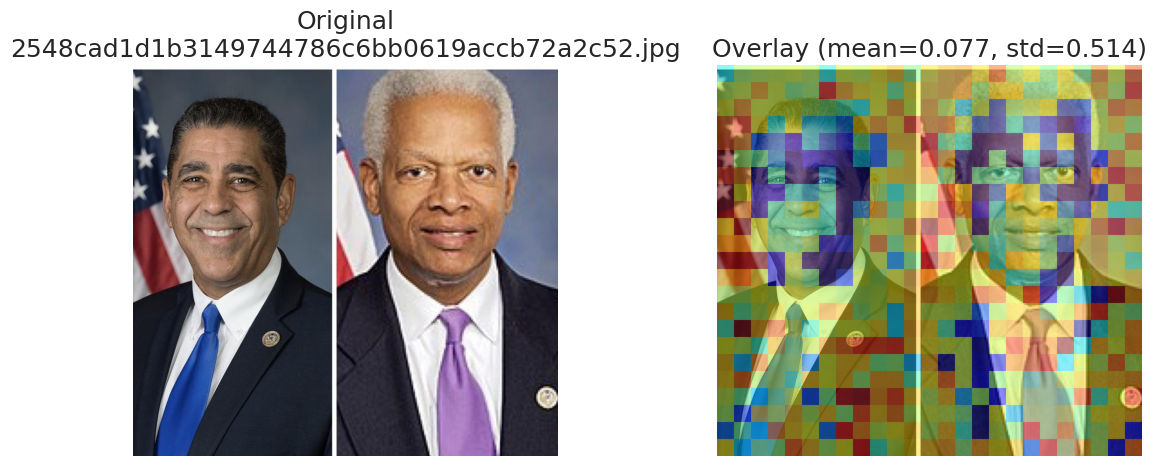

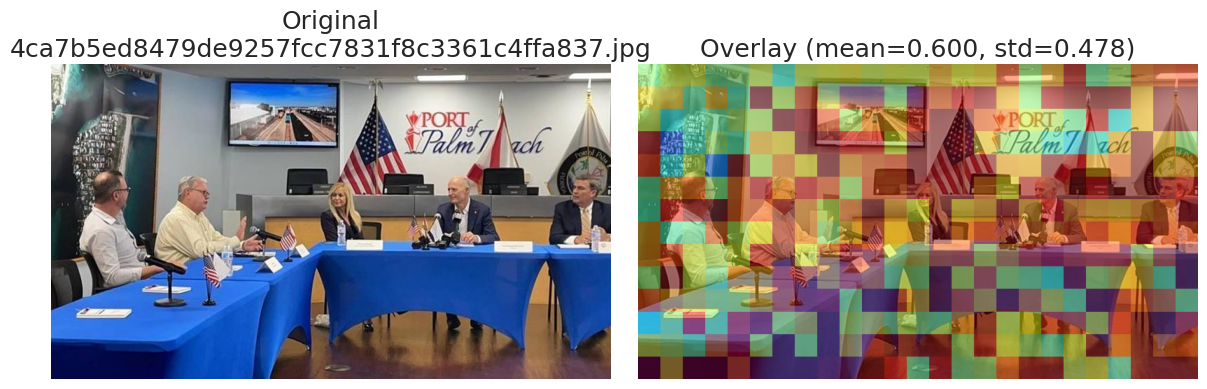

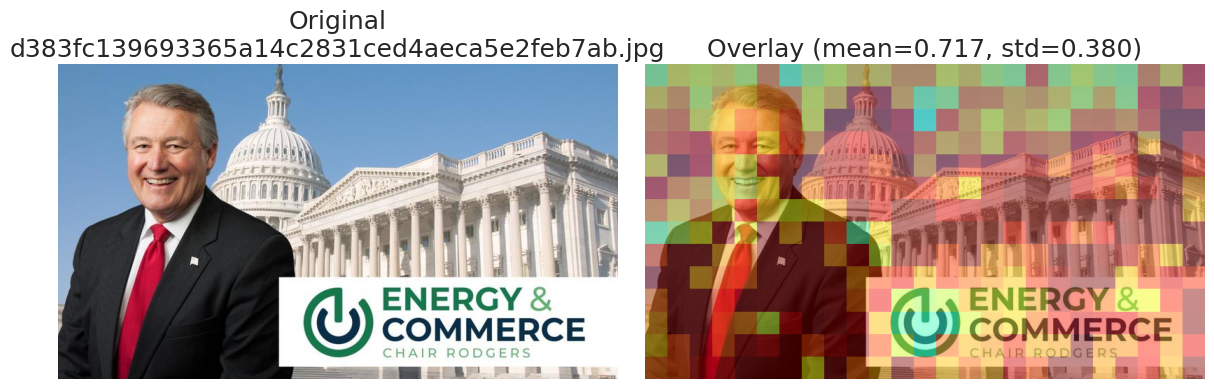

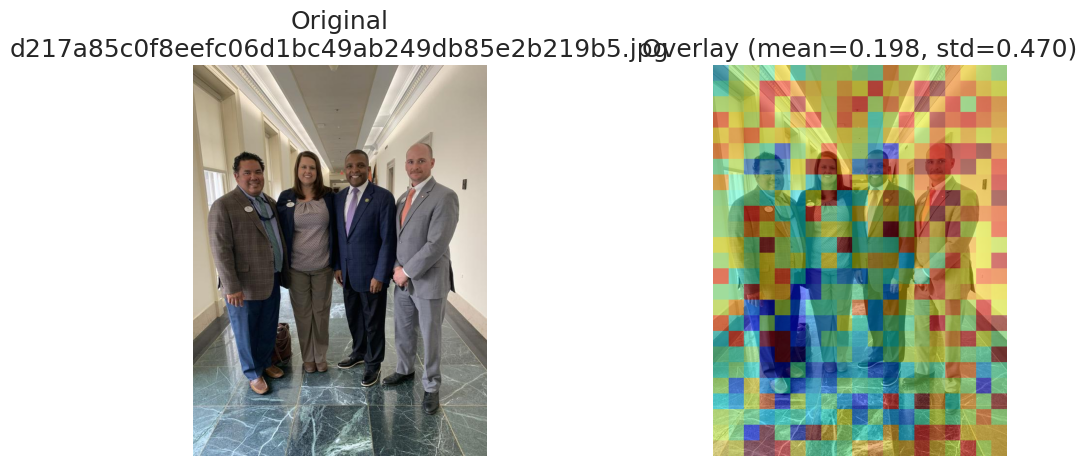

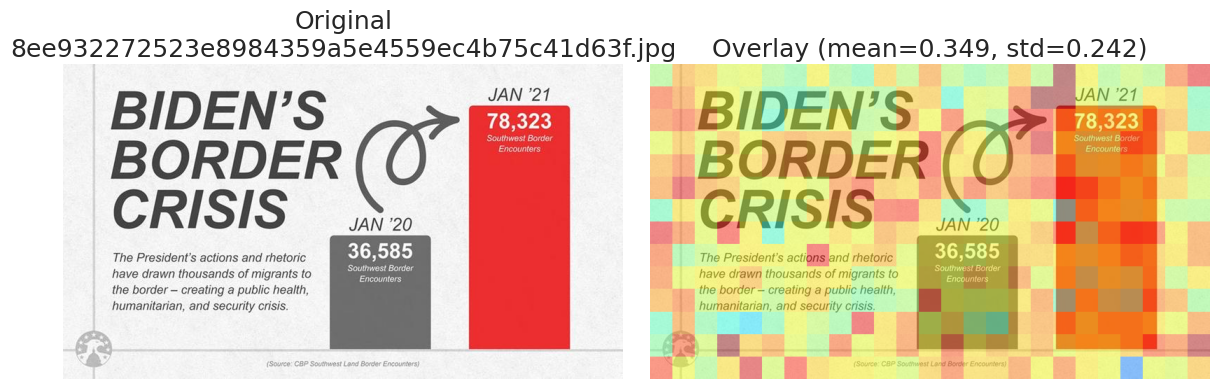

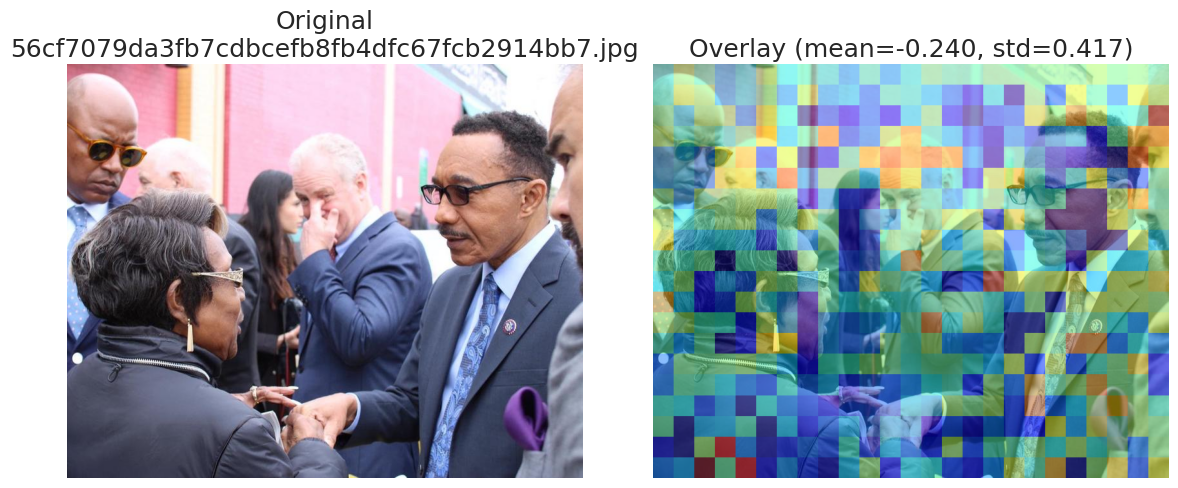

Join mode: record_name <-> url_name
Matched party labels: 1367/1367


,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_patch_std,mean_num_patches
0,Democrat,817,0.111699,0.094340,0.250157,NaN,413.175031
1,Republican,547,0.368059,0.391713,0.260589,NaN,417.751371


/scratch/local/jobs/49064715/ipykernel_3119155/3844479636.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
/scratch/local/jobs/49064715/ipykernel_3119155/3844479636.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
/scratch/local/jobs/49064715/ipykernel_3119155/3844479636.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax

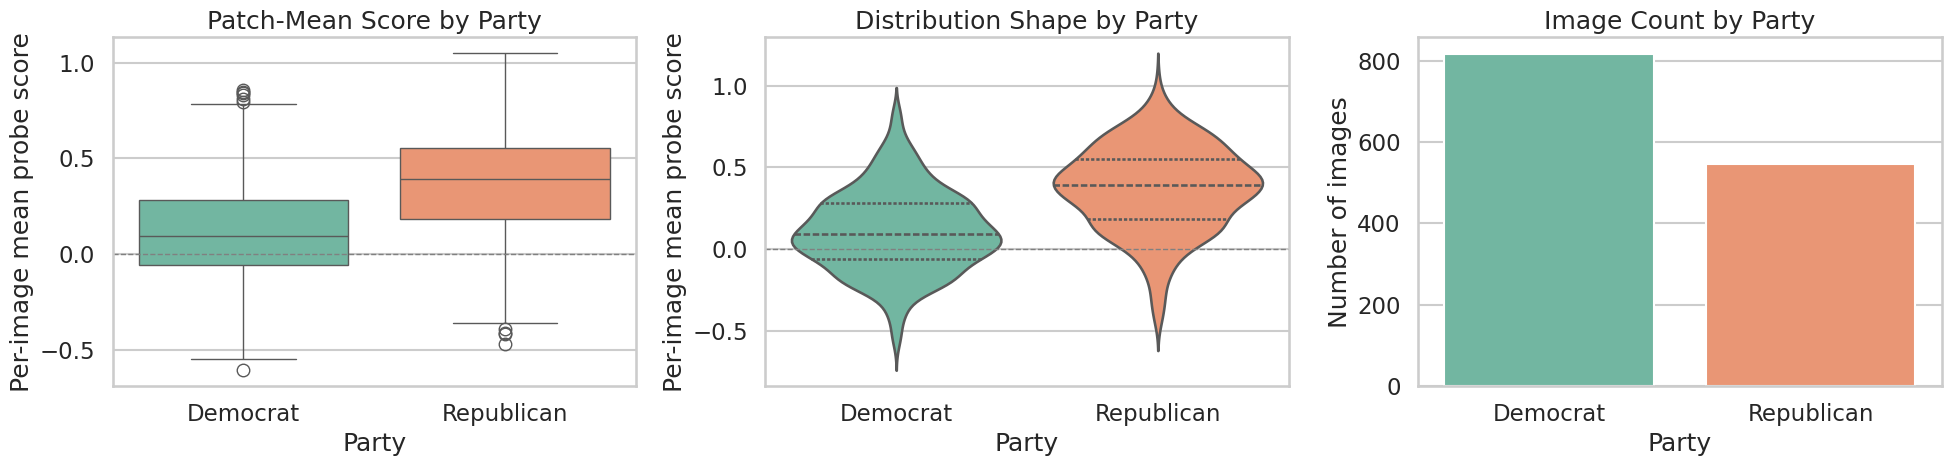

,party,q05,q25,q50,q75,q95
0,Democrat,-0.250430,-0.056894,0.094340,0.281071,0.556959
1,Republican,-0.074136,0.184512,0.391713,0.551668,0.763446


,metric,value
0,n_democrat,8.170000e+02
1,n_republican,5.470000e+02
2,mean_diff_rep_minus_dem,2.563605e-01
3,mean_diff_bootstrap_ci_low,2.284607e-01
4,mean_diff_bootstrap_ci_high,2.854577e-01
5,welch_t_stat,-1.809402e+01
6,welch_t_pvalue,1.645243e-64
7,mannwhitney_u_stat,1.037190e+05
8,mannwhitney_u_pvalue,2.756278e-63
9,cohens_d,1.007744e+00


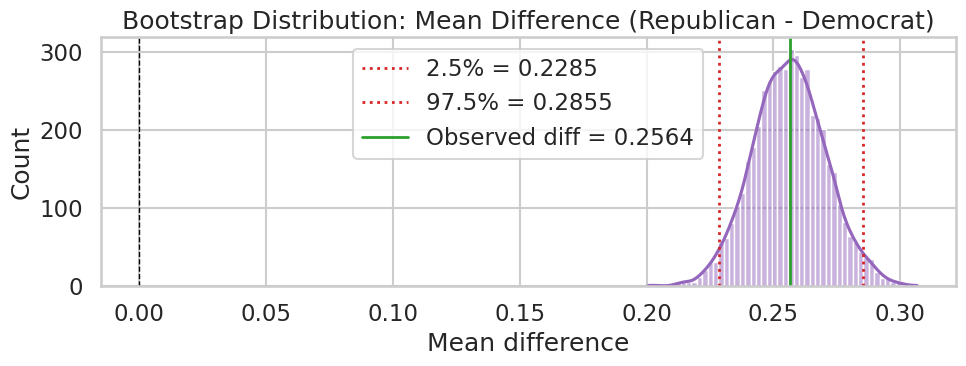

DW join mode: record_name <-> url_name
Rows with DW-NOMINATE match: 4968/5335


,metric,value
0,n_rows,4.968000e+03
1,n_unique_members,2.590000e+02
2,pearson_r,4.678238e-01
3,pearson_p,1.072971e-268
4,spearman_rho,4.382067e-01
5,spearman_p,3.025161e-232


,metric,value
0,member_level_n,2.590000e+02
1,member_level_pearson_r,6.122863e-01
2,member_level_pearson_p,4.862276e-28
3,member_level_spearman_rho,5.947507e-01
4,member_level_spearman_p,3.610257e-26


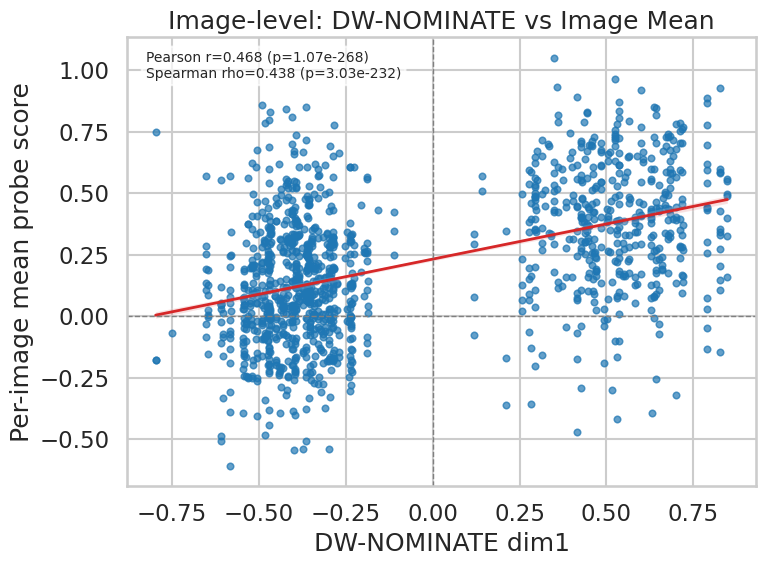

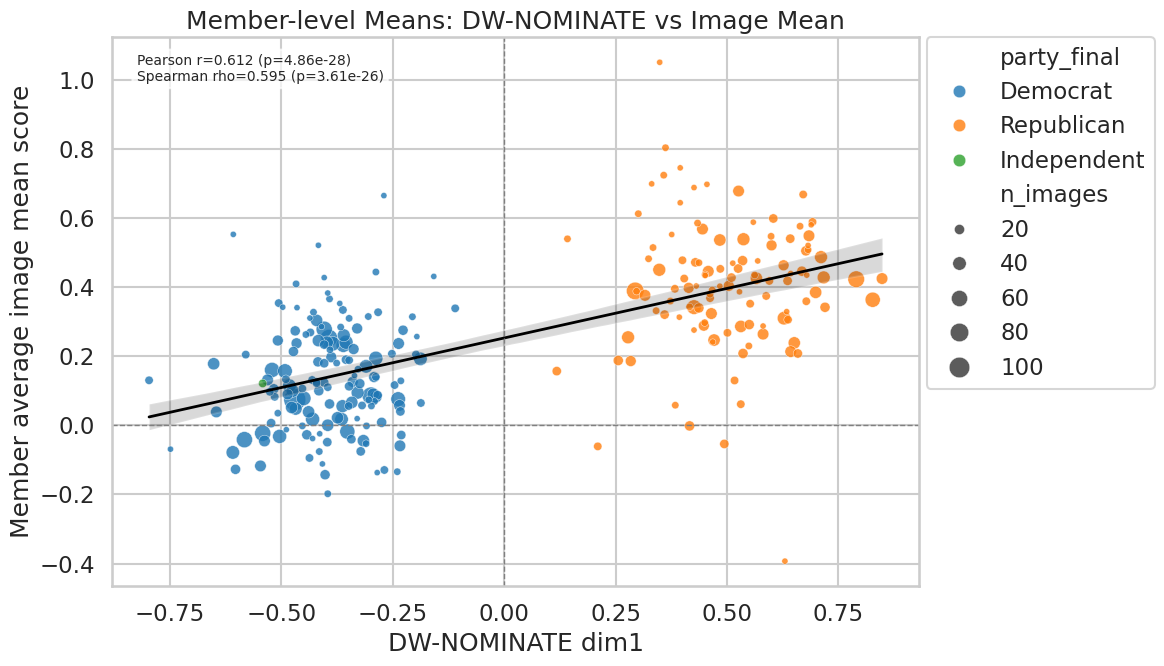

,bioguide,name,party_final,nominate_dim1,n_images,mean_image_score,std_image_score
0,E000296,Dwight Evans,Democrat,-0.470,116,0.074315,0.301164
1,T000468,Dina Titus,Democrat,-0.299,72,0.085419,0.246648
2,B001298,Don Bacon,Republican,0.294,72,0.388741,0.216903
3,T000460,Mike Thompson,Democrat,-0.393,68,0.252642,0.200586
4,C001098,Ted Cruz,Republican,0.790,64,0.422544,0.313098
5,E000297,Adriano Espaillat,Democrat,-0.583,60,-0.041448,0.273774
6,G000585,Jimmy Gomez,Democrat,-0.542,60,-0.022768,0.127603
7,C001091,Joaquin Castro,Democrat,-0.404,60,0.277955,0.267618
8,R000606,Jamie Raskin,Democrat,-0.521,52,0.160167,0.234344
9,M001111,Patty Murray,Democrat,-0.352,52,-0.018001,0.115091


In [8]:
def run_all(
    ridge_prefix,
    model_family="qwen3_vl",
    dataset="twitter",
    probe_name="headwise_linear",
    model_name=None,
    n_heatmap=6,
    seed=7,
):
    """
    Run full Twitter analysis for a ridge prefix.

    Works with both new token_scoring outputs and legacy twitter patch outputs.
    """
    print(f"\n{'='*60}")
    print(f"  Ridge prefix: {ridge_prefix}")
    print(f"  Model       : {model_family}")
    print(f"  Dataset     : {dataset}")
    print(f"  Probe       : {probe_name}")
    print(f"{'='*60}\n")

    payload, df_stats = load_outputs(
        ridge_prefix,
        model_family=model_family,
        dataset=dataset,
        probe_name=probe_name,
        model_name=model_name,
    )

    show_heatmap_examples(payload, n=n_heatmap, seed=seed)
    df_party = analyze_party_comparison(df_stats)
    analyze_statistical_inference(df_party)
    analyze_dw_nominate(df_stats)


run_all(
    "combined_ideology",
    model_family="qwen3_vl",
    dataset="twitter",
    probe_name="headwise_linear",
)


In [9]:
def compare_member_level_correlations_across_scenarios(
    ridge_prefixes=("politician", "combined_ideology"),
    models=("qwen3_vl", "gemma4"),
    probes=("headwise_linear", "layerwise_linear", "layerwise_rfm"),
    dataset="twitter",
    meta_path=Path("data/twitter_images_metadata.csv"),
    leg_path=Path("data/legislators_116_119_with_twitter.csv"),
    dw_path=Path("data/HS116_members.csv"),
):
    """
    Compare member-level DW-NOMINATE correlations across all scenarios:
    ridge_prefix x model x probe.

    Returns one row per scenario with member-level Pearson/Spearman stats.
    """
    for p in [meta_path, leg_path, dw_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing required file: {p}")

    df_meta = pd.read_csv(meta_path)
    df_leg = pd.read_csv(leg_path)
    df_dw = pd.read_csv(dw_path)

    # Precompute lookup tables used by every scenario.
    df_meta = df_meta.copy()
    df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
    df_meta["filename"] = df_meta["filename"].astype(str)
    df_meta["screen_key"] = df_meta["screen_name"].astype(str).str.strip().str.lower().str.lstrip("@")

    df_leg = df_leg.copy()
    df_leg["twitter_key"] = df_leg["twitter"].astype(str).str.strip().str.lower().str.lstrip("@")
    df_leg_small = df_leg[["twitter_key", "bioguide", "name", "party"]].copy()

    df_dw = df_dw.copy()
    df_dw = df_dw[df_dw["congress"] == 116].copy()
    df_dw["bioguide_id"] = df_dw["bioguide_id"].astype(str)
    df_dw_small = (
        df_dw[["bioguide_id", "nominate_dim1", "nominate_dim2", "party_code", "bioname"]]
        .dropna(subset=["bioguide_id", "nominate_dim1"])
        .drop_duplicates("bioguide_id")
    )

    rows = []

    for ridge_prefix in ridge_prefixes:
        for model_family in models:
            for probe_name in probes:
                scenario = f"{ridge_prefix} | {model_family} | {probe_name}"
                try:
                    _, df_stats = load_outputs(
                        ridge_prefix=ridge_prefix,
                        model_family=model_family,
                        dataset=dataset,
                        probe_name=probe_name,
                    )

                    df_img = df_stats.copy()

                    # Normalize score and naming columns for mixed legacy/new outputs.
                    if "mean" not in df_img.columns:
                        if "mean_image_token_score" in df_img.columns:
                            df_img["mean"] = df_img["mean_image_token_score"]
                        elif "image_mean" in df_img.columns:
                            df_img["mean"] = df_img["image_mean"]
                        else:
                            raise ValueError("No score column found for scenario")

                    if "image_path" in df_img.columns:
                        df_img["image_basename"] = df_img["image_path"].astype(str).apply(lambda p: Path(p).name)
                    else:
                        df_img["image_basename"] = None

                    if "image_name" not in df_img.columns:
                        if "record_name" in df_img.columns:
                            df_img["image_name"] = df_img["record_name"].astype(str)
                        else:
                            df_img["image_name"] = df_img["image_basename"].astype(str)
                    else:
                        df_img["image_name"] = df_img["image_name"].astype(str)

                    # Pick the metadata join that gives most screen-name matches.
                    candidate_left_keys = [
                        k for k in ["image_name", "image_basename", "record_name"] if k in df_img.columns
                    ]
                    candidate_right_keys = ["url_name", "filename"]

                    best_df = None
                    best_match_count = -1
                    best_mode = None

                    for left_key in candidate_left_keys:
                        for right_key in candidate_right_keys:
                            df_try = df_img.merge(
                                df_meta[[right_key, "screen_key", "party"]].drop_duplicates(right_key),
                                how="left",
                                left_on=left_key,
                                right_on=right_key,
                            )
                            match_count = int(df_try["screen_key"].notna().sum())
                            if match_count > best_match_count:
                                best_match_count = match_count
                                best_df = df_try
                                best_mode = f"{left_key} <-> {right_key}"

                    if best_df is None:
                        raise RuntimeError("No valid metadata join mode")

                    df_join = (
                        best_df.merge(
                            df_leg_small,
                            how="left",
                            left_on="screen_key",
                            right_on="twitter_key",
                        )
                        .merge(df_dw_small, how="left", left_on="bioguide", right_on="bioguide_id")
                    )

                    df_corr = df_join.dropna(subset=["nominate_dim1", "mean", "bioguide"]).copy()
                    if len(df_corr) < 10:
                        rows.append(
                            {
                                "ridge_prefix": ridge_prefix,
                                "model": model_family,
                                "probe": probe_name,
                                "scenario": scenario,
                                "join_mode": best_mode,
                                "n_rows": int(len(df_corr)),
                                "n_members": 0,
                                "pearson_r": np.nan,
                                "pearson_p": np.nan,
                                "spearman_rho": np.nan,
                                "spearman_p": np.nan,
                                "status": "too_few_rows",
                            }
                        )
                        print(f"  {scenario}: too few rows ({len(df_corr)})")
                        continue

                    member_agg = (
                        df_corr.groupby(["bioguide", "nominate_dim1"], as_index=False)
                        .agg(
                            n_images=("mean", "size"),
                            mean_image_score=("mean", "mean"),
                        )
                        .sort_values("n_images", ascending=False)
                        .reset_index(drop=True)
                    )

                    if len(member_agg) < 3:
                        rows.append(
                            {
                                "ridge_prefix": ridge_prefix,
                                "model": model_family,
                                "probe": probe_name,
                                "scenario": scenario,
                                "join_mode": best_mode,
                                "n_rows": int(len(df_corr)),
                                "n_members": int(len(member_agg)),
                                "pearson_r": np.nan,
                                "pearson_p": np.nan,
                                "spearman_rho": np.nan,
                                "spearman_p": np.nan,
                                "status": "too_few_members",
                            }
                        )
                        print(f"  {scenario}: too few members ({len(member_agg)})")
                        continue

                    pearson_r, pearson_p = scipy_stats.pearsonr(
                        member_agg["nominate_dim1"],
                        member_agg["mean_image_score"],
                    )
                    spearman_rho, spearman_p = scipy_stats.spearmanr(
                        member_agg["nominate_dim1"],
                        member_agg["mean_image_score"],
                    )

                    rows.append(
                        {
                            "ridge_prefix": ridge_prefix,
                            "model": model_family,
                            "probe": probe_name,
                            "scenario": scenario,
                            "join_mode": best_mode,
                            "n_rows": int(len(df_corr)),
                            "n_members": int(len(member_agg)),
                            "pearson_r": float(pearson_r),
                            "pearson_p": float(pearson_p),
                            "spearman_rho": float(spearman_rho),
                            "spearman_p": float(spearman_p),
                            "status": "ok",
                        }
                    )

                    print(
                        f"  {scenario}: n_members={len(member_agg)}, "
                        f"pearson={pearson_r:.4f}, spearman={spearman_rho:.4f}"
                    )

                except FileNotFoundError:
                    rows.append(
                        {
                            "ridge_prefix": ridge_prefix,
                            "model": model_family,
                            "probe": probe_name,
                            "scenario": scenario,
                            "join_mode": None,
                            "n_rows": 0,
                            "n_members": 0,
                            "pearson_r": np.nan,
                            "pearson_p": np.nan,
                            "spearman_rho": np.nan,
                            "spearman_p": np.nan,
                            "status": "missing_files",
                        }
                    )
                    print(f"  {scenario}: missing files")
                except Exception as e:
                    rows.append(
                        {
                            "ridge_prefix": ridge_prefix,
                            "model": model_family,
                            "probe": probe_name,
                            "scenario": scenario,
                            "join_mode": None,
                            "n_rows": 0,
                            "n_members": 0,
                            "pearson_r": np.nan,
                            "pearson_p": np.nan,
                            "spearman_rho": np.nan,
                            "spearman_p": np.nan,
                            "status": f"error: {str(e)}",
                        }
                    )
                    print(f"  {scenario}: error - {str(e)}")

    out = pd.DataFrame(rows)
    out = out.sort_values(["ridge_prefix", "model", "probe"]).reset_index(drop=True)
    return out


print("Computing member-level correlations across all scenarios...\n")
scenario_corr = compare_member_level_correlations_across_scenarios(
    ridge_prefixes=("politician", "combined_ideology"),
    models=("qwen3_vl", "gemma4"),
    probes=("headwise_linear", "layerwise_linear", "layerwise_rfm"),
    dataset="twitter",
)

print("\n=== Full Scenario Table ===")
display(scenario_corr)

ok_corr = scenario_corr[scenario_corr["status"] == "ok"].copy()
if ok_corr.empty:
    print("No successful scenarios to summarize.")
else:
    print("\n=== Ranked by |Pearson r| ===")
    display(ok_corr.assign(abs_pearson=lambda d: d["pearson_r"].abs()).sort_values("abs_pearson", ascending=False))

    print("\n=== Summary by Ridge Prefix ===")
    display(
        ok_corr.groupby("ridge_prefix", as_index=False).agg(
            n_scenarios=("scenario", "size"),
            mean_pearson_r=("pearson_r", "mean"),
            mean_spearman_rho=("spearman_rho", "mean"),
            mean_n_members=("n_members", "mean"),
        )
    )


Computing member-level correlations across all scenarios...

  politician | qwen3_vl | headwise_linear: missing files
  politician | qwen3_vl | layerwise_linear: missing files
  politician | qwen3_vl | layerwise_rfm: missing files
  politician | gemma4 | headwise_linear: missing files
  politician | gemma4 | layerwise_linear: missing files
  politician | gemma4 | layerwise_rfm: missing files
Loaded mode  : new
Loaded scores: results/token_scoring/qwen3_vl/twitter/prompt_image_token_scores_combined_ideology_headwise_linear.pt
Loaded stats : results/token_scoring/qwen3_vl/twitter/prompt_token_stats_combined_ideology_headwise_linear.csv
Num records  : 1367
Metadata:


model_path                  /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
model_family                                                        qwen3-vl
mode                                                                  vision
probe                                                        headwise_linear
prefix                                                     combined_ideology
top_k                                                                     16
data                             data/probes/twitter_images_score_data.jsonl
num_records                                                             1367
num_records_with_images                                                 1367
image_token_ids                                                     [151655]
probe_weights_path         results/probes/qwen3-vl-8b-instruct/combined_i...
probe_scores_path          results/probes/qwen3-vl-8b-instruct/combined_i...
probe_metadata_path        results/probes/qwen3-vl-8b-instruct/combined_i...

  combined_ideology | qwen3_vl | headwise_linear: n_members=259, pearson=0.6123, spearman=0.5948
Loaded mode  : new
Loaded scores: results/token_scoring/qwen3_vl/twitter/prompt_image_token_scores_combined_ideology_layerwise_linear.pt
Loaded stats : results/token_scoring/qwen3_vl/twitter/prompt_token_stats_combined_ideology_layerwise_linear.csv
Num records  : 1367
Metadata:


model_path                  /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
model_family                                                        qwen3-vl
mode                                                                  vision
probe                                                       layerwise_linear
prefix                                                     combined_ideology
top_k                                                                     16
data                             data/probes/twitter_images_score_data.jsonl
num_records                                                             1367
num_records_with_images                                                 1367
image_token_ids                                                     [151655]
probe_weights_path         results/probes/qwen3-vl-8b-instruct/combined_i...
probe_scores_path          results/probes/qwen3-vl-8b-instruct/combined_i...
probe_metadata_path        results/probes/qwen3-vl-8b-instruct/combined_i...

  combined_ideology | qwen3_vl | layerwise_linear: n_members=259, pearson=0.6353, spearman=0.6305
Loaded mode  : new
Loaded scores: results/token_scoring/qwen3_vl/twitter/prompt_image_token_scores_combined_ideology_layerwise_rfm.pt
Loaded stats : results/token_scoring/qwen3_vl/twitter/prompt_token_stats_combined_ideology_layerwise_rfm.csv
Num records  : 1367
Metadata:


...

,ridge_prefix,model,probe,scenario,join_mode,n_rows,n_members,pearson_r,pearson_p,spearman_rho,spearman_p,status
0,combined_ideology,gemma4,headwise_linear,combined_ideology | gemma4 | headwise_linear,record_name <-> url_name,4968,259,0.742580,1.216936e-46,0.710575,4.068160e-41,ok
1,combined_ideology,gemma4,layerwise_linear,combined_ideology | gemma4 | layerwise_linear,record_name <-> url_name,4968,259,0.714351,9.938610e-42,0.688712,9.308336e-38,ok
2,combined_ideology,gemma4,layerwise_rfm,combined_ideology | gemma4 | layerwise_rfm,record_name <-> url_name,4968,259,0.678529,2.717180e-36,0.676711,4.891540e-36,ok
3,combined_ideology,qwen3_vl,headwise_linear,combined_ideology | qwen3_vl | headwise_linear,record_name <-> url_name,4968,259,0.612286,4.862276e-28,0.594751,3.610257e-26,ok
4,combined_ideology,qwen3_vl,layerwise_linear,combined_ideology | qwen3_vl | layerwise_linear,record_name <-> url_name,4968,259,0.635264,1.125907e-30,0.630475,4.158352e-30,ok
5,combined_ideology,qwen3_vl,layerwise_rfm,combined_ideology | qwen3_vl | layerwise_rfm,record_name <-> url_name,4968,259,0.606254,2.205217e-27,0.593339,5.048977e-26,ok
6,politician,gemma4,headwise_linear,politician | gemma4 | headwise_linear,NaN,0,0,NaN,NaN,NaN,NaN,missing_files
7,politician,gemma4,layerwise_linear,politician | gemma4 | layerwise_linear,NaN,0,0,NaN,NaN,NaN,NaN,missing_files
8,politician,gemma4,layerwise_rfm,politician | gemma4 | layerwise_rfm,NaN,0,0,NaN,NaN,NaN,NaN,missing_files
9,politician,qwen3_vl,headwise_linear,politician | qwen3_vl | headwise_linear,NaN,0,0,NaN,NaN,NaN,NaN,missing_files



=== Ranked by |Pearson r| ===


,ridge_prefix,model,probe,scenario,join_mode,n_rows,n_members,pearson_r,pearson_p,spearman_rho,spearman_p,status,abs_pearson
0,combined_ideology,gemma4,headwise_linear,combined_ideology | gemma4 | headwise_linear,record_name <-> url_name,4968,259,0.742580,1.216936e-46,0.710575,4.068160e-41,ok,0.742580
1,combined_ideology,gemma4,layerwise_linear,combined_ideology | gemma4 | layerwise_linear,record_name <-> url_name,4968,259,0.714351,9.938610e-42,0.688712,9.308336e-38,ok,0.714351
2,combined_ideology,gemma4,layerwise_rfm,combined_ideology | gemma4 | layerwise_rfm,record_name <-> url_name,4968,259,0.678529,2.717180e-36,0.676711,4.891540e-36,ok,0.678529
4,combined_ideology,qwen3_vl,layerwise_linear,combined_ideology | qwen3_vl | layerwise_linear,record_name <-> url_name,4968,259,0.635264,1.125907e-30,0.630475,4.158352e-30,ok,0.635264
3,combined_ideology,qwen3_vl,headwise_linear,combined_ideology | qwen3_vl | headwise_linear,record_name <-> url_name,4968,259,0.612286,4.862276e-28,0.594751,3.610257e-26,ok,0.612286
5,combined_ideology,qwen3_vl,layerwise_rfm,combined_ideology | qwen3_vl | layerwise_rfm,record_name <-> url_name,4968,259,0.606254,2.205217e-27,0.593339,5.048977e-26,ok,0.606254



=== Summary by Ridge Prefix ===


,ridge_prefix,n_scenarios,mean_pearson_r,mean_spearman_rho,mean_n_members
0,combined_ideology,6,0.664877,0.649094,259.0
